In [2]:
import logging
import sys
logger = logging.getLogger('cosipy')
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(sys.stdout))
from cosipy.util import fetch_wasabi_file

# dependencies for response
import numpy as np
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord, cartesian_to_spherical, Galactic
from astropy.io import fits
from astropy.time import Time
from astropy.table import Table
import matplotlib.pyplot as plt

# dependencies for plotting mollweide projections
from mhealpy import HealpixMap, HealpixBase
import healpy as hp
import pandas as pd
from pathlib import Path

# This is cosi.response
from scoords import Attitude, SpacecraftFrame
from cosipy.response import FullDetectorResponse, DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import test_data
from histpy import Histogram, HealpixAxis, Axis, Axes
import gc

# This is cosi.BinnedData
from cosipy import BinnedData, UnBinnedData
# this is for fitting and forward folding (#3ML is needed for spectral modeling)
from threeML import Model, Powerlaw
from astromodels import Band


# This is cosi_image_deconvolution
from cosipy.image_deconvolution import SpacecraftAttitudeExposureTable, CoordsysConversionMatrix, DataIF_COSI_DC2, ImageDeconvolution
from cosipy.util import fetch_wasabi_file
from cosipy.ts_map.TSMap import TSMap

# dependencies for data handling
import shutil
import os
from hashlib import md5

/home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/utils/file_utils.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


00:25:58 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=584842;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=670136;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#47\47]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=810040;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=489382;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#68\68]8;;\
                  will not be available.                                                                           

00:25:59 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=837575;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=125747;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=437370;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=701370;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

...

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=818768;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=354821;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=68816;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=226462;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=715480;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=28122;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=562666;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=768702;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=125491;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=229774;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [3]:
# ----------------------------------------------------------------------------------------------------------------------------
path_to_Source = "COSI-SMEX/DC3/Data/Sources/"
# Source file
Fe60_Source_file= "60Fe_NE2001_3months_unbinned_data_filtered_with_SAAcut.fits.gz"

# ----------------------------------------------------------------------------------------------------------------------------
path_to_Ori = "COSI-SMEX/DC3/Data/Orientation/"
#oritnation file
ori_file = "DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"

# ----------------------------------------------------------------------------------------------------------------------------
# response file
response_file_Fe60_high = "Response60FeHigh.o4.e1329_1336.s10201526728102.m1287.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5.zip"
response_file_Fe60_low = "Response60FeLow.o4.e1170_1176.s9552269354945.m1188.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5.zip"

# ----------------------------------------------------------------------------------------------------------------------------
path_to_bkg= "COSI-SMEX/DC3/Data/Backgrounds/Ge/" 
path_to_bkg_binned= "COSI-SMEX/DC3/Data/Backgrounds/Ge/Binned_BG_Files/"
#background files
albedo_bkg_file = "AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
Fe60_high_bkg_file = "Total_BG_3months_binned_for_Fe60High_filtered_with_SAAcut.hdf5"
Fe60_low_bkg_file = "Total_BG_3months_binned_for_Fe60Low_filtered_with_SAAcut.hdf5"



# #----------------------------------------------------------------------------------------------------------------------------
# # for some reason the source and bkg file are remained zipped
# # Source file
# fetch_wasabi_file(path_to_Source + Fe60_Source_file, unzip=True, checksum='21e65cd5684fd2671be983368e0908a0')

# #----------------------------------------------------------------------------------------------------------------------------
# #Background files
# # fetch_wasabi_file(path_to_bkg + albedo_bkg_file)
# fetch_wasabi_file((path_to_bkg_binned + Fe60_high_bkg_file))
# # fetch_wasabi_file((path_to_bkg_binned + Fe60_low_bkg_file))

# #----------------------------------------------------------------------------------------------------------------------------
# # ONLY RESPONSE FILE ARE UNZIPPED

# #response file
# fetch_wasabi_file("COSI-SMEX/DC3/Data/Responses/" + response_file_Fe60_high)
# # fetch_wasabi_file("COSI-SMEX/DC3/Data/Responses/" + response_file_Fe60_low)

# # Use unzip for .zip files, not gunzip
# os.system('unzip -o ' + response_file_Fe60_high)
# # os.system('unzip -o ' + response_file_Fe60_low)


# #----------------------------------------------------------------------------------------------------------------------------
# #oritnation file
# fetch_wasabi_file(path_to_Ori + ori_file, checksum='e5e71e3528e39b855b0e4f74a1a2eebe')


data_path = "data/"

# psichi
# 3720

In [ ]:
%matplotlib inline
source = BinnedData("inputs.yaml")
# this one is used when
source.get_binned_data(unbinned_data = data_path + Fe60_Source_file, psichi_binning="galactic", make_binning_plots=plot, show_plots=plot)

binning data...
Time unit: s
Em unit: keV
Phi unit: deg
PsiChi unit: None


In [ ]:
binned_bkg = BinnedData("inputs.yaml")
# this one is used when
binned_bkg.load_binned_data_from_hdf5(data_path + Fe60_high_bkg_file)

In [5]:
signal = source.binned_data.to_dense()  
bkg = binned_bkg.binned_data.to_dense()  

event = signal + bkg

In [6]:
signal.write(data_path + "Fe60_galactic_signal.hdf5", overwrite = True)
bkg.write(data_path + "Fe60_galactic_bkg.hdf5", overwrite = True)
event.write(data_path + "Fe60_galactic_event.hdf5", overwrite = True)

In [38]:
signal = Histogram.open(data_path + "Fe60_galactic_signal.hdf5")
bkg = Histogram.open(data_path + "Fe60_galactic_bkg.hdf5")
event = Histogram.open(data_path + "Fe60_galactic_event.hdf5")

In [ ]:
response_path = data_path + response_file_Fe60_high.replace(".zip", "")
response = FullDetectorResponse.open(response_path)

ori = SpacecraftFile.parse_from_file(data_path + ori_file)

time_int = signal.axes['Time'].edges

In [28]:
ccm = CoordsysConversionMatrix.time_binning_ccm(response, ori, time_int)

  0%|          | 0/1 [00:00<?, ?it/s]

In [87]:
# binned_event = Histogram.open(data_path + "Fe60_galactic_event.hdf5")
# binned_bkg = Histogram.open(data_path + Fe60_high_bkg_file)

binned_event = BinnedData("inputs.yaml")
binned_event.load_binned_data_from_hdf5(data_path + "Fe60_galactic_event.hdf5")

binned_bkg = BinnedData("inputs.yaml")
binned_bkg.load_binned_data_from_hdf5(data_path + Fe60_high_bkg_file)


response_path = data_path + response_file_Fe60_high.replace(".zip", "")
response = FullDetectorResponse.open(response_path)


ccm = CoordsysConversionMatrix.open(data_path + "Fe60_galactic_ccm.hdf5")
# exposure_table = SpacecraftAttitudeExposureTable.from_fits(data_path+"exposure_table_Fe60.fits")
ori = SpacecraftFile.parse_from_file(data_path + ori_file)

In [90]:
# Find spatial axes (HealpixAxis) and show their coordinate systems
print(binned_event.binned_data.axes['PsiChi'].coordsys)
print(binned_bkg.binned_data.axes['PsiChi'].coordsys) 
print(response.axes['NuLambda'].coordsys)
print(ccm.axes['lb'].coordsys)

ori.frame

<Galactic Frame>
<Galactic Frame>
<SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>
<Galactic Frame>


'galactic'

In [53]:
%%time

data_interface = DataIF_COSI_DC2.load(name = "Fe60",
                                      event_binned_data = binned_event.binned_data,
                                      dict_bkg_binned_data = {"Fe60 High": binned_bkg.binned_data},
                                      rsp = response,
                                      coordsys_conv_matrix=ccm)

Loading the response matrix onto your computer memory...
Finished
... checking the axis Time of the event and background files...
    --> pass (edges)
... checking the axis Em of the event and background files...
    --> pass (edges)
... checking the axis Phi of the event and background files...
    --> pass (edges)
... checking the axis PsiChi of the event and background files...
    --> pass (edges)
...checking the axis Em of the event and response files...
    --> pass (edges)
...checking the axis Phi of the event and response files...
    --> pass (edges)
...checking the axis PsiChi of the event and response files...
    --> pass (edges)
The axes in the event and background files are redefined. Now they are consistent with those of the response file.
Calculating an exposure map...
Finished
... checking the axis Time of the event and background files...
    --> pass (edges)
... checking the axis Em of the event and background files...
    --> pass (edges)
... checking the axis Phi o

In [56]:
print(response.axes.labels)
print(binned_event.binned_data.axes.labels)

['NuLambda' 'Ei' 'Em' 'Phi' 'PsiChi']
['Time' 'Em' 'Phi' 'PsiChi']


In [64]:
parameter_filepath = "imagedeconvolution_Fe60.yml"

In [65]:
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(parameter_filepath)


In [66]:
image_deconvolution.initialize()

#### Initialization Starts ####
<< Instantiating the model class AllSkyImage >>
---- parameters ----
coordinate: galactic
energy_edges:
  unit: keV
  value:
  - 1329.0
  - 1336.0
nside: 16
scheme: ring
unit: cm-2 s-1 sr-1

<< Setting initial values of the created model object >>
---- parameters ----
algorithm: flat
parameter:
  unit: cm-2 s-1 sr-1
  value:
  - 1e-4

<< Registering the deconvolution algorithm >>
Gaussian filter with FWHM of 2.0 deg will be applied to delta images ...
---- parameters ----
algorithm: RL
parameter:
  acceleration:
    activate: true
    alpha_max: 10.0
  background_normalization_optimization:
    activate: true
    range:
      Fe60 High:
      - 0.01
      - 10.0
  iteration_max: 100
  response_weighting:
    activate: true
    index: 0.5
  save_results:
    activate: false
    directory: ./results
    only_final_result: true
  smoothing: true
  smoothing_FWHM:
    unit: deg
    value: 2.0
  stopping_criteria:
    statistics: log-likelihood
    threshold:

In [67]:
print(image_deconvolution._check_model_response_consistency())


True


In [68]:
image_deconvolution.run_deconvolution()

#### Image Deconvolution Starts ####
<< Initialization >>
The response weighting filter was calculated.
The expected count histograms were calculated with the initial model map.


  0%|          | 0/100 [00:00<?, ?it/s]

## Iteration 1/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
  alpha: 1.0
  background_normalization: {'Fe60 High': 0.8539088740794731}
  loglikelihood: [26189.278764845105]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 2/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>


...

<< Registering Result >>
  alpha: 1.0
  background_normalization: {'Fe60 High': 1.000368013267412}
  loglikelihood: [35216.01660495793]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 99/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
  alpha: 1.0
  background_normalization: {'Fe60 High': 1.0003680083103554}
  loglikelihood: [35216.51771187538]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 100/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
  alpha: 1.0
  background_normalization: {'Fe60 High': 1.0003680060527786}
  loglikelihood: [35217.0121148015]
<< Checking Stopping Criteria >>
--> Stop
<< Finalization >>
#### Image Deconvolution Finished ####


In [69]:
image_deconvolution.results

[{'iteration': 1,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x7ebf36c44310>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x7ebf36c44880>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x7ebf36c44d60>,
  'background_normalization': {'Fe60 High': 0.8539088740794731},
  'alpha': 1.0,
  'loglikelihood': [26189.278764845105]},
 {'iteration': 2,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x7ebf3d59c9a0>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x7ebf36c790f0>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x7ebf36c7a350>,
  'background_normalization': {'Fe60 High': 0.8867298369334936},
  'alpha': 1.0,
  'loglikelihood': [28952.619065353472]},
 {'iteration': 3,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x7ebf3cc9cca0>,
  'delta_model': <cosipy.image_deconvolu

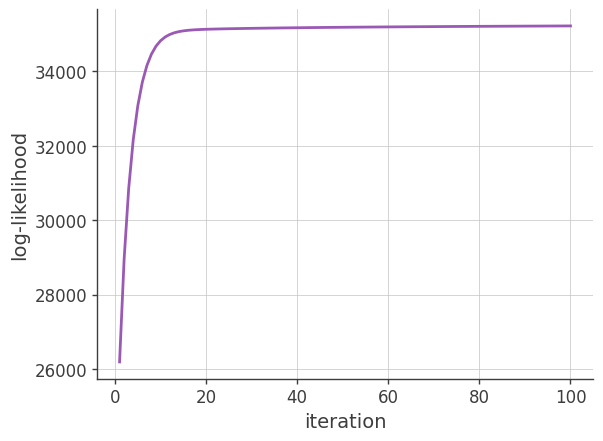

In [70]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['loglikelihood'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("log-likelihood")
plt.show()

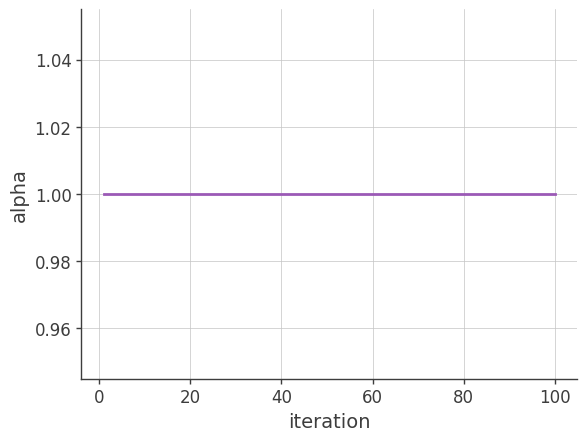

In [71]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['alpha'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("alpha")
plt.show()

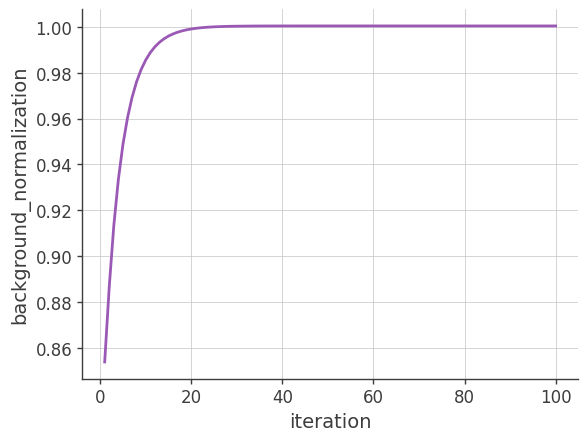

In [72]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['background_normalization']['Fe60 High'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("background_normalization")
plt.show()

In [107]:
def plot_reconstructed_image(result, source_position = None): # source_position should be (l,b) in degrees
    iteration = result['iteration']
    image = result['model']

    for energy_index in range(image.axes['Ei'].nbins):
        map_healpxmap = HealpixMap(data = image[:,energy_index], unit = image.unit)

        _, ax = map_healpxmap.plot('mollview')        
        
        _.colorbar.set_label(str(image.unit))
        
        if source_position is not None:
            ax.scatter(source_position[0]*u.deg, source_position[1]*u.deg, transform=ax.get_transform('world'), color = 'red')

        plt.title(label = f"iteration = {iteration}, energy_index = {energy_index} ({image.axes['Ei'].bounds[energy_index][0]}-{image.axes['Ei'].bounds[energy_index][1]})")

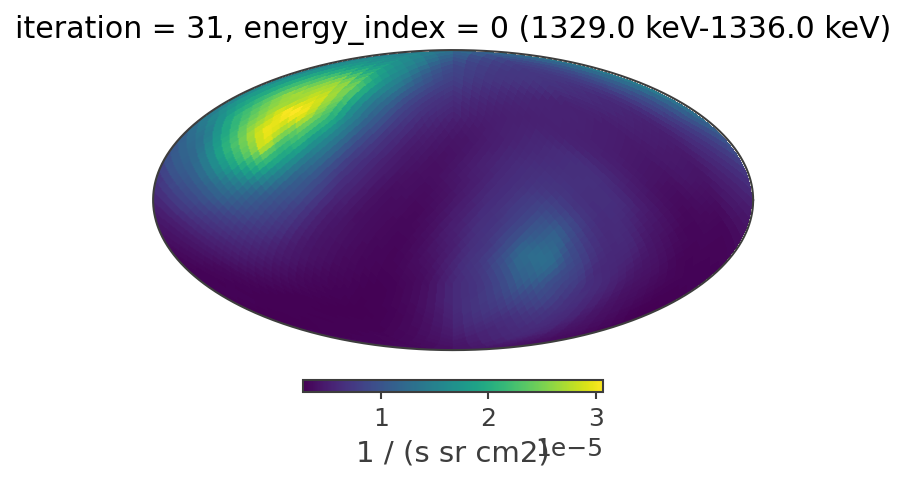

In [111]:
iteration = 30

# Add source position (l, b) in degrees - example for Fe-60 source
# You can change these coordinates to wherever you want the source marker
source_pos = (0.0, 0.0)  # Galactic center as example, change as needed

plot_reconstructed_image(image_deconvolution.results[iteration])

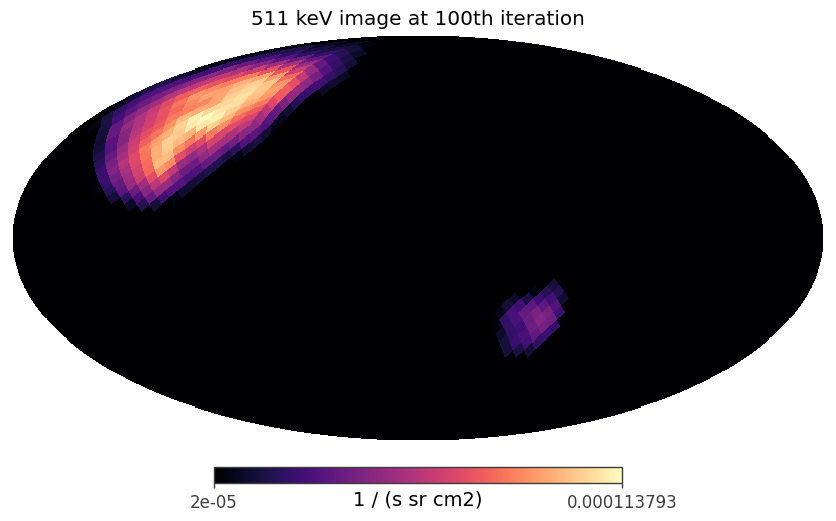

In [106]:
iteration_idx = 99

result = image_deconvolution.results[iteration_idx]

iteration = result['iteration']
image = result['model']

data = image[:,0]
data[data <= 0 * data.unit] = 1e-12 * data.unit

hp.mollview(data, min = 2e-5, norm ='log', unit = str(data.unit), title = f'511 keV image at {iteration}th iteration', cmap = 'magma')

plt.show()